# ACT Demo: Verification with VNNLib

Complete verification workflow using ACT framework with VNNLib benchmarks:
1. **Model Loading**: Load VNNLib benchmark and synthesize models
2. **Verification**: IntervalTF (forward bounds) + DualTF (certified bounds)
3. **Analysis**: Spurious counterexample inference

In [1]:
# Setup and imports
import sys, os 
import io
from contextlib import redirect_stdout

f = io.StringIO()
# with redirect_stdout(f):
#     from act.front_end.vnnlib_loader.create_specs import VNNLibSpecCreator
#     from act.front_end.model_synthesis import synthesize_models_from_specs
act_root = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
sys.path.insert(0, act_root) if act_root not in sys.path else None

import logging
# Configure logging: suppress verbose INFO logs from vnnlib_loader
logging.getLogger('act.front_end.vnnlib_loader').setLevel(logging.ERROR)
import torch
import matplotlib.pyplot as plt
import numpy as np
import yaml
from pathlib import Path
from collections import Counter

# Force reload modules
import importlib
modules_to_reload = [
    'act.front_end.model_synthesis',
    'act.front_end.vnnlib_loader.create_specs',
]
for mod_name in modules_to_reload:
    if mod_name in sys.modules:
        importlib.reload(sys.modules[mod_name])

from act.front_end.vnnlib_loader.create_specs import VNNLibSpecCreator
from act.front_end.model_synthesis import synthesize_models_from_specs
from act.pipeline.verification.torch2act import TorchToACT
from act.back_end.dual_tf import DualTF, compute_forward_bounds, compute_dual_bound
from act.back_end.analyze import analyze, initialize_tf_mode
from act.back_end.core import Bounds, Fact, ConSet

# CIFAR-100 class names
CIFAR100_CLASSES = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
    'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

from act.util.device_manager import initialize_device
initialize_device(device="cuda", dtype="float32")

print("Setup complete")

[ACT] Auto-detecting project root: ..
[WARN] Gurobi license not found: ../modules/gurobi/gurobi.lic
[INFO] Please place gurobi.lic in: ../modules/gurobi
✅ Device Manager Initialized: device=cuda:0, dtype=torch.float32
Setup complete


## Step 1: Load VNNLib Benchmark and Synthesize Models

In [2]:
print("="*80)
print("LOADING CIFAR-100 VNNLIB BENCHMARK")
print("="*80)

creator = VNNLibSpecCreator(config_name="vnnlib_default")
spec_results = creator.create_specs_for_data_model_pairs(
    categories=["cifar100_2024"],
    max_instances=3,
    validate_shapes=True
)
print(f"Loaded {len(spec_results)} instances\n")

print("Synthesizing wrapped models...")
wrapped_models = synthesize_models_from_specs(spec_results)
print(f"Synthesized {len(wrapped_models)} wrapped model(s)\n")

wrapped_models_list = list(wrapped_models.values())
wrapped_model = wrapped_models_list[0]

input_layer = wrapped_model[0]
labeled_input = input_layer.labeled_input
input_spec_layer = wrapped_model[1]
input_spec = input_spec_layer.spec
epsilon = float((input_spec.ub - input_spec.lb).max())

labels = labeled_input.label
if labels.dim() == 0:
    labels = labels.unsqueeze(0)
N = labels.shape[0]

instance_info = []
for i in range(N):
    instance_info.append({
        "index": i,
        "true_label": int(labels[i].item()),
        "input_tensor": labeled_input.tensor[i] if labeled_input.tensor.shape[0] > 1 else labeled_input.tensor[0],
        "epsilon": epsilon,
    })
    print(f"Instance {i}: {CIFAR100_CLASSES[int(labels[i].item())]} (label={int(labels[i].item())}), eps={epsilon:.6f}")

print(f"\nReady for batch verification ({N} instances)")

LOADING CIFAR-100 VNNLIB BENCHMARK
Loaded 3 instances

Synthesizing wrapped models...

🧬 Synthesizing models from 3 spec result(s)...

🎉 Synthesis Complete:
   Total specs: 3
   Wrapped models: 1
Synthesized 1 wrapped model(s)

Instance 0: worm (label=99), eps=0.030590
Instance 1: sea (label=71), eps=0.030590
Instance 2: castle (label=17), eps=0.030590

Ready for batch verification (3 instances)


## Step 2: Convert to ACT Net + Batch Input Bounds

In [3]:
print("="*80)
print("CONVERTING TO ACT NET (shared model, batched instances)")
print("="*80)

converter = TorchToACT(wrapped_model)
act_net = converter.run()

print(f"ACT layers: {len(act_net.layers)}")
all_vars = [v for layer in act_net.layers for v in layer.out_vars]
total_vars = max(all_vars) + 1 if all_vars else 0
print(f"Variables: {total_vars}")

lb_batch = input_spec.lb.flatten(start_dim=1)  # [N, 3, 32, 32] -> [N, 3072]
ub_batch = input_spec.ub.flatten(start_dim=1)
true_labels = [info["true_label"] for info in instance_info]
B = lb_batch.shape[0]
num_classes = 100

print(f"Batch: {B} instances, input shape: {lb_batch.shape}")
for i, info in enumerate(instance_info):
    print(f'  [{i}] {CIFAR100_CLASSES[info["true_label"]]} (label={info["true_label"]})')

print(f"\nNetwork structure (first 5 and last 3 layers):")
for i, layer in enumerate(act_net.layers[:5]):
    print(f"  {i:2d}. {layer.kind:15s} | Out vars: {len(layer.out_vars):6d}")
print("  ...")
for i, layer in enumerate(act_net.layers[-3:], len(act_net.layers)-3):
    print(f"  {i:2d}. {layer.kind:15s} | Out vars: {len(layer.out_vars):6d}")

CONVERTING TO ACT NET (shared model, batched instances)
ACT layers: 81
Variables: 427564
Batch: 3 instances, input shape: torch.Size([3, 3072])
  [0] worm (label=99)
  [1] sea (label=71)
  [2] castle (label=17)

Network structure (first 5 and last 3 layers):
   0. INPUT           | Out vars:   9216
   1. INPUT_SPEC      | Out vars:   9216
   2. CONV2D          | Out vars:  14400
   3. SCALE           | Out vars:  14400
   4. BIAS            | Out vars:  14400
  ...
  78. RELU            | Out vars:    100
  79. DENSE           | Out vars:    100
  80. ASSERT          | Out vars:    100


## Step 3: Batched IntervalTF - Layer-by-Layer Bounds

In [4]:
print("="*80)
print("BATCHED INTERVAL BOUNDS PROPAGATION")
print("="*80)

print(f"Batch input: {lb_batch.shape} ({B} instances x {lb_batch.shape[1]} features)")
print("\nRunning BATCHED IntervalTF (all instances simultaneously)...")
initialize_tf_mode("interval")

import time
entry_bounds = Bounds(lb=lb_batch, ub=ub_batch)
entry_fact = Fact(bounds=entry_bounds, cons=ConSet())
entry_id = act_net.layers[0].id

t0 = time.time()
before, after, globalC = analyze(act_net, entry_id, entry_fact)
t_interval = time.time() - t0

bounds_dict = {lid: fact.bounds for lid, fact in after.items()}
print(f"Computed bounds for {len(bounds_dict)} layers in {t_interval:.2f}s")

output_layer = act_net.layers[-2]
output_bounds = bounds_dict.get(output_layer.id)
if output_bounds is not None:
    print(f"\nOutput bounds shape: {output_bounds.lb.shape}")
    for i in range(B):
        width = (output_bounds.ub[i] - output_bounds.lb[i]).mean().item()
        print(f"  [{i}] {CIFAR100_CLASSES[true_labels[i]]}: mean width = {width:.4f}")

BATCHED INTERVAL BOUNDS PROPAGATION
Batch input: torch.Size([3, 3072]) (3 instances x 3072 features)

Running BATCHED IntervalTF (all instances simultaneously)...
Computed bounds for 81 layers in 0.17s

Output bounds shape: torch.Size([3, 100])
  [0] worm: mean width = nan
  [1] sea: mean width = nan
  [2] castle: mean width = nan


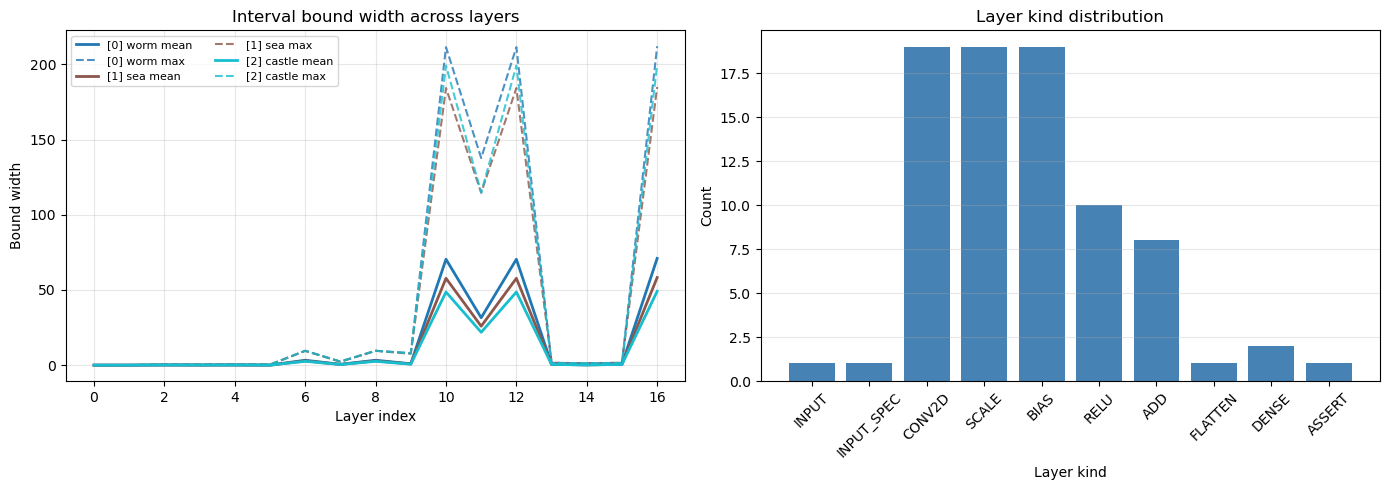

In [5]:
# Bounds propagation visualization (batch-aware)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
layer_positions = []
mean_widths = {i: [] for i in range(B)}
max_widths = {i: [] for i in range(B)}

for layer_idx, layer in enumerate(act_net.layers):
    bounds = bounds_dict.get(layer.id)
    if bounds is None:
        continue
    width = (bounds.ub - bounds.lb).detach().cpu().float().numpy()
    if width.ndim == 1:
        width = width.reshape(1, -1)
    elif width.ndim > 2:
        width = width.reshape(width.shape[0], -1)

    layer_positions.append(layer_idx)
    batch_here = min(B, width.shape[0])
    for inst_idx in range(B):
        if inst_idx < batch_here:
            finite_width = width[inst_idx][np.isfinite(width[inst_idx])]
            mean_width = float(finite_width.mean()) if finite_width.size else np.nan
            max_width = float(finite_width.max()) if finite_width.size else np.nan
        else:
            mean_width = np.nan
            max_width = np.nan
        mean_widths[inst_idx].append(mean_width)
        max_widths[inst_idx].append(max_width)

colors = plt.cm.tab10(np.linspace(0, 1, max(B, 1)))
for inst_idx in range(B):
    class_name = CIFAR100_CLASSES[true_labels[inst_idx]]
    axes[0].plot(layer_positions, mean_widths[inst_idx], color=colors[inst_idx], linewidth=2,
                 label=f"[{inst_idx}] {class_name} mean")
    axes[0].plot(layer_positions, max_widths[inst_idx], color=colors[inst_idx], linestyle="--", alpha=0.8,
                 label=f"[{inst_idx}] {class_name} max")

axes[0].set_title("Interval bound width across layers")
axes[0].set_xlabel("Layer index")
axes[0].set_ylabel("Bound width")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8, ncol=2)

kind_counts = Counter(layer.kind for layer in act_net.layers)
axes[1].bar(list(kind_counts.keys()), list(kind_counts.values()), color="steelblue")
axes[1].set_title("Layer kind distribution")
axes[1].set_xlabel("Layer kind")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, axis="y", alpha=0.3)

fig.tight_layout()
plt.show()

## Step 4: Batched DualTF - Robust Classification Bounds

In [6]:
print("="*80)
print("BATCHED DUAL TF VERIFICATION")
print("="*80)

print(f"\nComputing BATCHED forward bounds ({B} instances)...")
t0 = time.time()
dual_bounds_dict = compute_forward_bounds(act_net, lb_batch, ub_batch, post_activation=True)
t_fwd = time.time() - t0
print(f"Forward bounds: {len(dual_bounds_dict)} layers in {t_fwd:.2f}s")

dual_tf = DualTF()

print(f"\nComputing robust bounds per instance...")
t0 = time.time()
results = []
for i in range(B):
    label = true_labels[i]
    margin, cert = dual_tf.compute_robust_bound(act_net, dual_bounds_dict, label, num_classes)
    results.append({"label": label, "margin": margin[i].item(), "certified": cert[i].item()})
t_bwd = time.time() - t0

print(f"Backward pass: {t_bwd:.2f}s")
print(f"\n{"Instance":<10} {"Class":<20} {"Label":>6} {"Min Margin":>12} {"Status":<15}")
print("-"*65)
for i, r in enumerate(results):
    status = "CERTIFIED" if r["certified"] else "NOT CERTIFIED"
    print(f"  [{i}]     {CIFAR100_CLASSES[r["label"]]:<20} {r["label"]:>6} {r["margin"]:>12.6f} {status}")

n_cert = sum(1 for r in results if r["certified"])
print(f"\nTotal: {n_cert}/{B} certified")

BATCHED DUAL TF VERIFICATION

Computing BATCHED forward bounds (3 instances)...


Forward bounds: 81 layers in 0.06s

Computing robust bounds per instance...
Backward pass: 1.01s

Instance   Class                 Label   Min Margin Status         
-----------------------------------------------------------------
  [0]     worm                     99    -6.847068 NOT CERTIFIED
  [1]     sea                      71    -5.237740 NOT CERTIFIED
  [2]     castle                   17    -7.502191 NOT CERTIFIED

Total: 0/3 certified


## Step 4b: Forward vs Backward Bound Comparison (All Instances)

In [7]:
print("="*80)
print("FORWARD vs BACKWARD BOUND COMPARISON (ALL INSTANCES)")
print("="*80)

dual_output_layer = act_net.layers[-2]
dual_output_bounds = dual_bounds_dict.get(dual_output_layer.id)

for i in range(B):
    label = true_labels[i]
    print(f"\n--- Instance [{i}]: {CIFAR100_CLASSES[label]} (label={label}) ---")
    print(f"  {"Class":<6} {"Name":<15} {"Forward":>12} {"Backward":>12} {"Improvement":>12} {"Status"}")
    print(f"  {"-"*6} {"-"*15} {"-"*12} {"-"*12} {"-"*12} {"-"*8}")

    with torch.no_grad():
        inp = instance_info[i]["input_tensor"]
        if inp.dim() == 3: inp = inp.unsqueeze(0)
        out = wrapped_model(inp)
        if isinstance(out, dict): out = out["output"]
        top5 = torch.topk(out[0], k=6).indices.tolist()

    for tc in top5:
        if tc == label: continue
        fwd_margin = (dual_output_bounds.lb[i, label] - dual_output_bounds.ub[i, tc]).item()
        c = torch.zeros(num_classes, dtype=dual_output_bounds.lb.dtype, device=dual_output_bounds.lb.device)
        c[label], c[tc] = 1.0, -1.0
        bwd_margin = dual_tf.compute_bound(act_net, dual_bounds_dict, c)[i].item()
        imp = bwd_margin - fwd_margin
        st = "TIGHTER" if imp > 1e-6 else "-"
        print(f"  {tc:<6} {CIFAR100_CLASSES[tc]:<15} {fwd_margin:>12.4f} {bwd_margin:>12.4f} {imp:>+12.4f} [{st}]")

FORWARD vs BACKWARD BOUND COMPARISON (ALL INSTANCES)

--- Instance [0]: worm (label=99) ---
  Class  Name                 Forward     Backward  Improvement Status
  ------ --------------- ------------ ------------ ------------ --------
  45     lobster               1.0469       2.4783      +1.4314 [TIGHTER]
  78     snake                 0.3982       5.0722      +4.6741 [TIGHTER]
  26     crab                  1.0135       6.6273      +5.6139 [TIGHTER]
  10     bowl                  0.2593       5.9122      +5.6528 [TIGHTER]
  50     mouse                 0.7043       5.2726      +4.5683 [TIGHTER]

--- Instance [1]: sea (label=71) ---
  Class  Name                 Forward     Backward  Improvement Status
  ------ --------------- ------------ ------------ ------------ --------
  30     dolphin               0.7137      -2.8206      -3.5342 [-]
  73     shark                 0.4625       4.5388      +4.0763 [TIGHTER]
  27     crocodile            -0.6115       2.0491      +2.6606 [TIGHT

## Step 5: Spurious Counterexample Analysis (All Instances)

In [8]:
print("="*80)
print("SPURIOUS COUNTEREXAMPLE ANALYSIS (ALL INSTANCES)")
print("="*80)

for inst_idx in range(B):
    label = true_labels[inst_idx]
    print(f"\n--- Instance [{inst_idx}]: {CIFAR100_CLASSES[label]} ---")

    with torch.no_grad():
        inp = instance_info[inst_idx]["input_tensor"]
        if inp.dim() == 3: inp = inp.unsqueeze(0)
        out = wrapped_model(inp)
        if isinstance(out, dict): out = out["output"]
        top5 = torch.topk(out[0], k=6).indices.tolist()

    adv_margins = []
    for tc in top5:
        if tc == label: continue
        c = torch.zeros(num_classes, dtype=lb_batch.dtype, device=lb_batch.device)
        c[label], c[tc] = 1.0, -1.0
        margin_all, sce_all = dual_tf.compute_bound(act_net, dual_bounds_dict, c, return_sce=True)
        m = margin_all[inst_idx].item()
        adv_margins.append((tc, m))

    adv_margins.sort(key=lambda x: x[1])
    print(f"  {"AdvClass":>9} | {"Name":<20} | {"Margin":>10} | {"Status"}")
    print(f"  {"-"*9}-+-{"-"*20}-+-{"-"*10}-+-{"-"*12}")
    for tc, m in adv_margins:
        st = "OK" if m > 0 else "VULNERABLE"
        print(f"  {tc:9d} | {CIFAR100_CLASSES[tc]:<20} | {m:10.4f} | {st}")

    wc, wm = adv_margins[0]
    print(f"  Most vulnerable: {wc} ({CIFAR100_CLASSES[wc]}), margin={wm:.6f}")

SPURIOUS COUNTEREXAMPLE ANALYSIS (ALL INSTANCES)

--- Instance [0]: worm ---
   AdvClass | Name                 |     Margin | Status
  ----------+----------------------+------------+-------------
         45 | lobster              |     2.4783 | OK
         78 | snake                |     5.0722 | OK
         50 | mouse                |     5.2726 | OK
         10 | bowl                 |     5.9122 | OK
         26 | crab                 |     6.6273 | OK
  Most vulnerable: 45 (lobster), margin=2.478339

--- Instance [1]: sea ---
   AdvClass | Name                 |     Margin | Status
  ----------+----------------------+------------+-------------
         30 | dolphin              |    -2.8206 | VULNERABLE
         95 | whale                |    -1.6528 | VULNERABLE
         27 | crocodile            |     2.0491 | OK
         12 | bridge               |     2.4000 | OK
         73 | shark                |     4.5388 | OK
  Most vulnerable: 30 (dolphin), margin=-2.820579

--- Instan

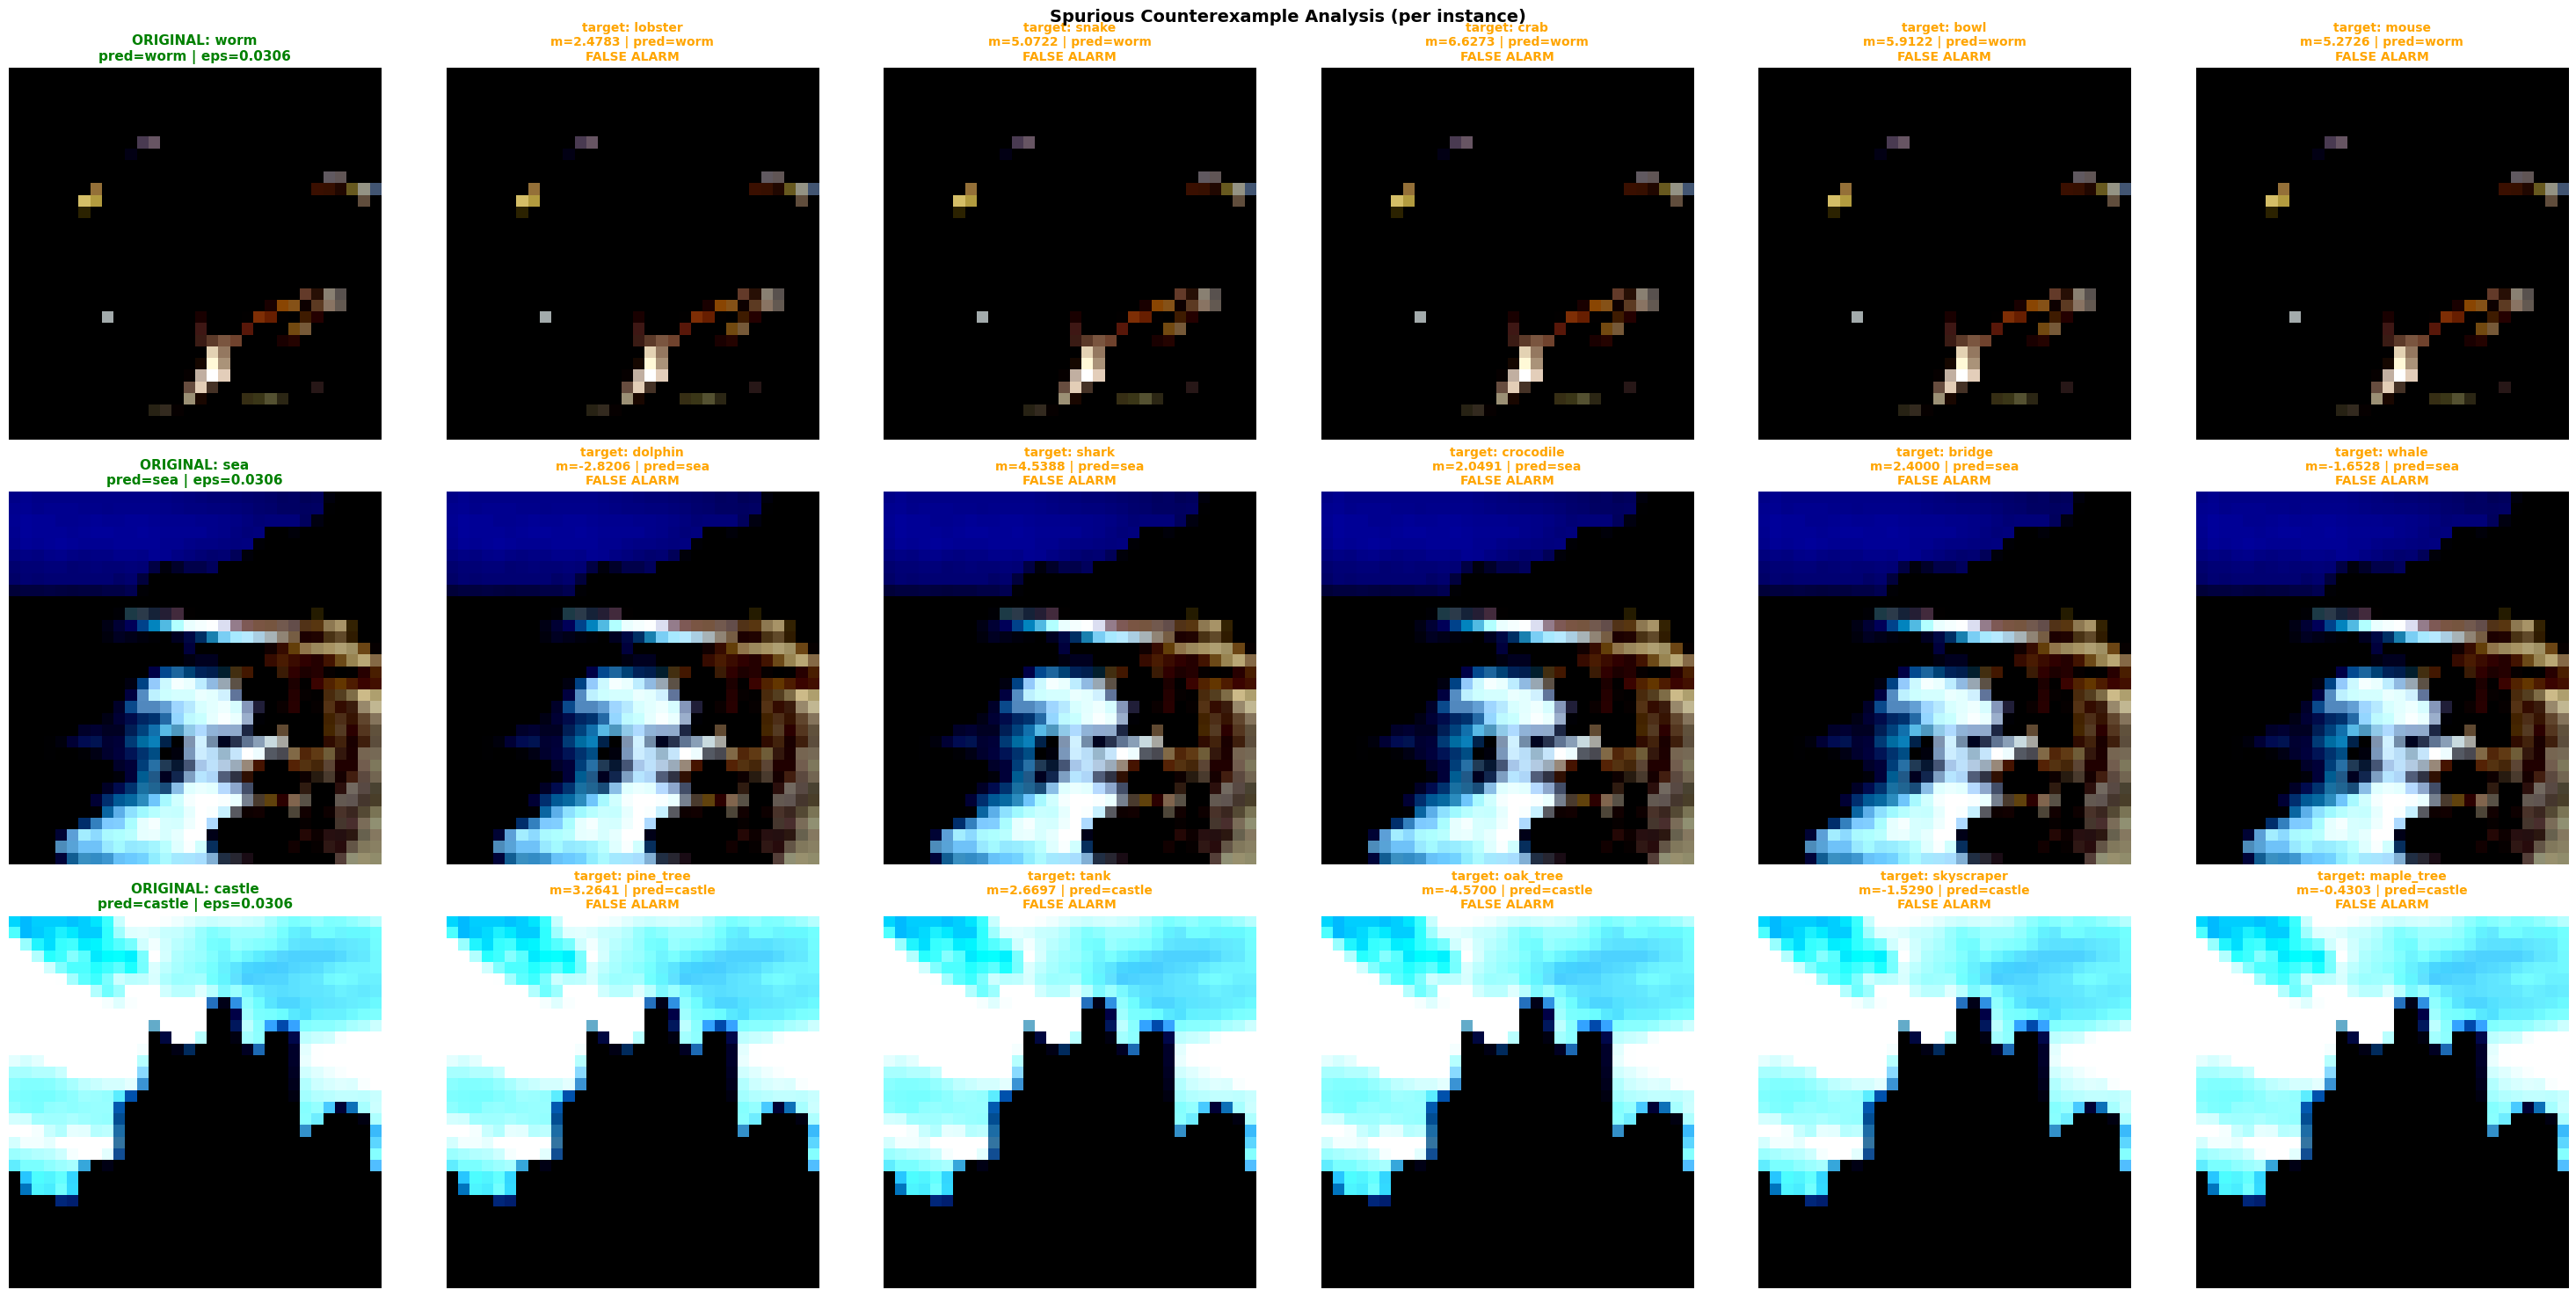

In [9]:
# Original vs SCE visualization for all batch instances
def _to_image(tensor_like):
    arr = tensor_like.detach().cpu().float().numpy() if hasattr(tensor_like, "detach") else np.asarray(tensor_like)
    if arr.ndim == 4:
        arr = arr[0]
    if arr.ndim == 1:
        arr = arr.reshape(3, 32, 32)
    if arr.ndim == 3 and arr.shape[0] == 3:
        arr = np.transpose(arr, (1, 2, 0))
    return np.clip(arr, 0.0, 1.0)

ref_bounds = next(iter(dual_bounds_dict.values()))
dtype = ref_bounds.lb.dtype
device = ref_bounds.lb.device
fig, axes = plt.subplots(B, 6, figsize=(30, B * 5))
if B == 1:
    axes = np.expand_dims(axes, axis=0)

for inst_idx in range(B):
    row_axes = axes[inst_idx]
    info = instance_info[inst_idx]
    label = info["true_label"]
    original_tensor = info["input_tensor"]
    if original_tensor.dim() == 4:
        original_tensor = original_tensor[0]
    original_batch = original_tensor.unsqueeze(0) if original_tensor.dim() == 3 else original_tensor

    with torch.no_grad():
        original_out = wrapped_model(original_batch)
        if isinstance(original_out, dict):
            original_out = original_out["output"]
        ranked_classes = torch.argsort(original_out[0], descending=True).tolist()
    top5_targets = [cls for cls in ranked_classes if cls != label][:5]

    original_img = _to_image(original_tensor)
    original_pred = int(original_out[0].argmax().item())
    row_axes[0].imshow(original_img)
    row_axes[0].set_title(
        f"ORIGINAL: {CIFAR100_CLASSES[label]}\npred={CIFAR100_CLASSES[original_pred]} | eps={info['epsilon']:.4f}",
        fontsize=11, color='green', fontweight='bold'
    )
    row_axes[0].axis("off")

    for col_idx, tc in enumerate(top5_targets, start=1):
        ax = row_axes[col_idx]
        c = torch.zeros(num_classes, dtype=dtype, device=device)
        c[label], c[tc] = 1.0, -1.0

        margin_all, sce_all = dual_tf.compute_bound(act_net, dual_bounds_dict, c, return_sce=True)
        margin_value = float(margin_all[inst_idx].item())

        # Extract SCE image for this instance: sce_all is [B, n]
        sce_flat = sce_all[inst_idx]  # [n]
        expected = 3 * 32 * 32
        if sce_flat.numel() >= expected:
            sce_img_tensor = sce_flat[:expected].reshape(3, 32, 32)
        else:
            sce_img_tensor = original_tensor.reshape(3, 32, 32).clone()

        # Run inference on SCE
        sce_batch = sce_img_tensor.unsqueeze(0)
        with torch.no_grad():
            sce_out = wrapped_model(sce_batch)
            if isinstance(sce_out, dict):
                sce_out = sce_out["output"]
            sce_pred = int(sce_out[0].argmax().item())

        ax.imshow(_to_image(sce_img_tensor))

        # Classify: false alarm vs real CE
        if sce_pred == label:
            verdict = "FALSE ALARM"
            color = "orange"
        elif sce_pred == tc:
            verdict = "REAL CE"
            color = "red"
        else:
            verdict = f"MISCLASS->{CIFAR100_CLASSES[sce_pred]}"
            color = "red"

        ax.set_title(
            f"target: {CIFAR100_CLASSES[tc]}\nm={margin_value:.4f} | pred={CIFAR100_CLASSES[sce_pred]}\n{verdict}",
            fontsize=10, color=color, fontweight='bold'
        )
        ax.axis("off")

fig.suptitle("Spurious Counterexample Analysis (per instance)", fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


## Step 6: Batch Verification Summary

In [10]:
print("="*80)
print("BATCH VERIFICATION SUMMARY")
print("="*80)

print(f"\nModel: CIFAR-100 ResNet Medium")
print(f"Instances: {B}")
print(f"Epsilon: {epsilon:.6f}")
print(f"Forward bounds time: {t_fwd:.2f}s (batched)")
print(f"Backward bounds time: {t_bwd:.2f}s ({B} labels)")

print(f"\n{"Instance":<10} {"Class":<20} {"Margin":>12} {"Certified"}")
print("-"*55)
for i, r in enumerate(results):
    mark = "YES" if r["certified"] else "NO"
    print(f"  [{i}]     {CIFAR100_CLASSES[r["label"]]:<20} {r["margin"]:>12.6f} {mark}")

n_cert = sum(1 for r in results if r["certified"])
print(f"\nCertified: {n_cert}/{B} ({100*n_cert/B:.0f}%)")
print("="*80)
print("BATCH VERIFICATION COMPLETE")
print("="*80)

BATCH VERIFICATION SUMMARY

Model: CIFAR-100 ResNet Medium
Instances: 3
Epsilon: 0.030590
Forward bounds time: 0.06s (batched)
Backward bounds time: 1.01s (3 labels)

Instance   Class                      Margin Certified
-------------------------------------------------------
  [0]     worm                    -6.847068 NO
  [1]     sea                     -5.237740 NO
  [2]     castle                  -7.502191 NO

Certified: 0/3 (0%)
BATCH VERIFICATION COMPLETE
